In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import os


In [3]:
# Load datasets
train_path = "train_data (1).csv"
valid_path = "valid_data (1).csv"

if not os.path.exists(train_path) or not os.path.exists(valid_path):
    raise FileNotFoundError("One or both dataset files not found. Please check the file paths.")

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)


In [4]:
train_df = train_df.dropna()
valid_df = valid_df.dropna()

In [5]:
print("Dataset Info:")
print(train_df.info())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nDuplicate Rows:", train_df.duplicated().sum())
print("\nData Sample:")
print(train_df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16990 entries, 0 to 16989
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16990 non-null  object
 1   label   16990 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 265.6+ KB
None

Missing Values:
text     0
label    0
dtype: int64

Duplicate Rows: 2

Data Sample:
                                                text  label
0  here are thursdays biggest analyst calls apple...      0
1  buy las vegas sands as travel to singapore bui...      0
2  piper sandler downgrades docusign to sell citi...      0
3  analysts react to teslas latest earnings break...      0
4  netflix and its peers are set for a return to ...      0


In [7]:
# Data Cleaning
train_df = train_df.drop_duplicates()
valid_df = valid_df.drop_duplicates()
train_df['text'] = train_df['text'].str.lower()
valid_df['text'] = valid_df['text'].str.lower()
train_df['text'] = train_df['text'].str.replace(r'http\S+|www\S+', '', regex=True)  # Remove URLs
valid_df['text'] = valid_df['text'].str.replace(r'http\S+|www\S+', '', regex=True)
train_df['text'] = train_df['text'].str.replace(r'[^A-Za-z0-9 ]', '', regex=True)  # Remove special characters
valid_df['text'] = valid_df['text'].str.replace(r'[^A-Za-z0-9 ]', '', regex=True)


In [9]:
# Save cleaned files
train_df.to_csv("clean_train.csv", index=False)
valid_df.to_csv("clean_valid.csv", index=False)

In [ ]:
# Load datasets
train_path = "clean_train.csv"
valid_path = "clean_valid.csv"



In [29]:
df_train = pd.read_csv(train_path)
df_valid = pd.read_csv(valid_path)

# Merge train and validation datasets
df = pd.concat([df_train, df_valid], ignore_index=True)

# Ensure required columns exist
required_columns = {'label', 'text'}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise KeyError(f"Missing columns in dataset: {', '.join(missing_columns)}")

# Convert label column to category (if not already)
df['label'] = df['label'].astype(str)
    

C:\Users\pruth\AppData\Local\Temp\ipykernel_22704\1674008307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['label'], palette='viridis', order=df['label'].value_counts().index)


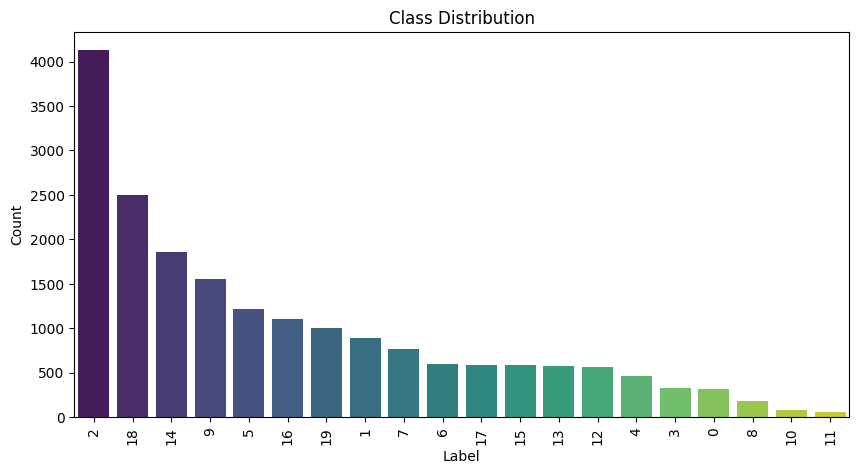

In [30]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['label'], palette='viridis', order=df['label'].value_counts().index)
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

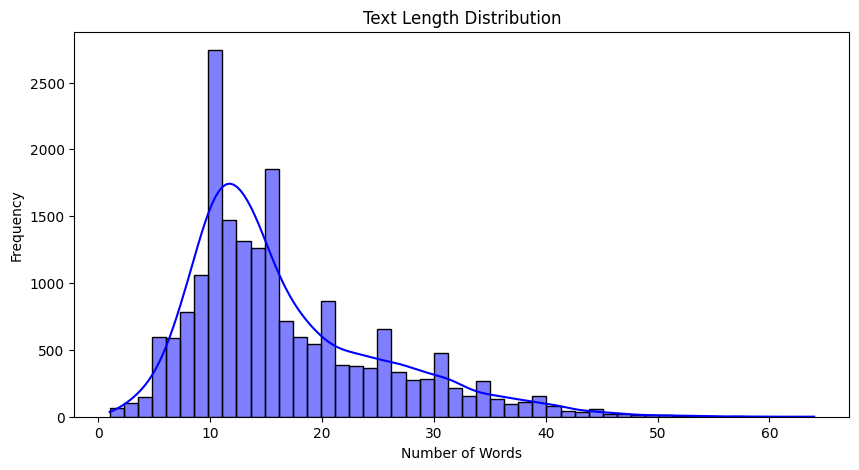

In [31]:
 # Problem 2: Text Length Distribution (Histogram)
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50, kde=True, color='blue')
plt.title('Text Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

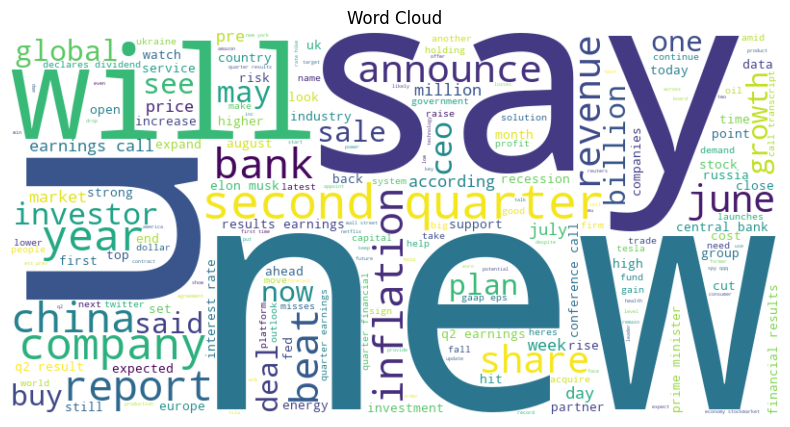

C:\Users\pruth\AppData\Local\Temp\ipykernel_22704\1794036995.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette='magma')


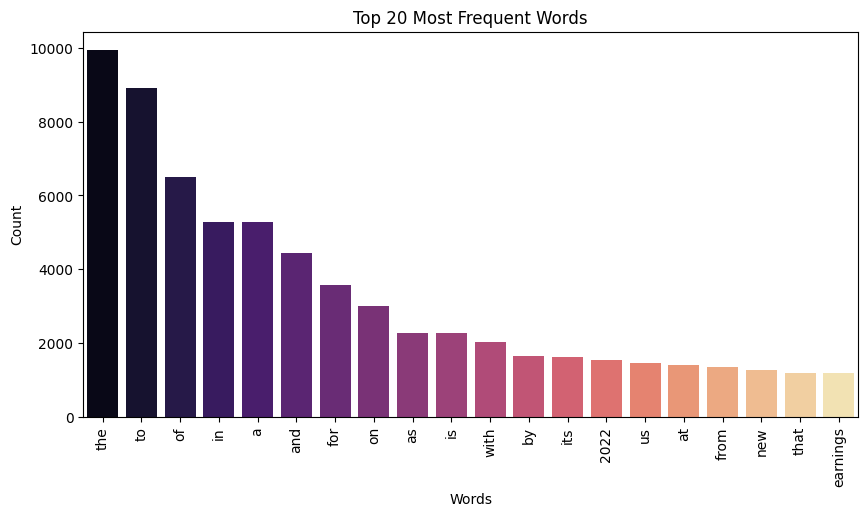

In [34]:
text_corpus = ' '.join(df['text'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_corpus)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()

# Generate bar chart for top 20 words
from collections import Counter
words = text_corpus.split()
word_counts = Counter(words).most_common(20)
words, counts = zip(*word_counts)
plt.figure(figsize=(10,5))
sns.barplot(x=list(words), y=list(counts), palette='magma')
plt.xticks(rotation=90)
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

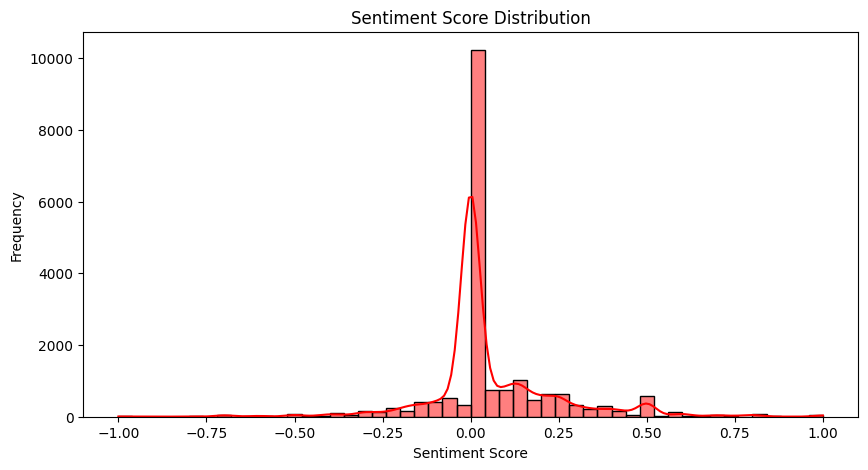

In [35]:
# Problem 4: Sentiment Analysis (Histogram)
df['sentiment'] = df['text'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
plt.figure(figsize=(10,5))
sns.histplot(df['sentiment'], bins=50, kde=True, color='red')
plt.title('Sentiment Score Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()